In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import sgd

import func

In [2]:
device = "cuda:0"

def align(u,v):
	return np.sum(u*v)/np.sqrt(np.sum(u**2)*np.sum(v**2))

def ortho_mat(k, d):
    A = np.random.randn(d, k)
    Q, _ = np.linalg.qr(A)
    return Q.T

In [3]:
d = 200
gamma = 0.5
k = int(gamma*d)

Delta = 0.01
sig = lambda x: torch.tanh(2*x)

beta = 0.7
v_np = np.array([p**(-beta) for p in range(1, k+1)])


v_np /= np.linalg.norm(v_np)
v0 = torch.tensor(v_np, dtype=torch.float32, device=device)


In [4]:
eta = 0.003
n_epoch = 10000
n_batch = 3
n_test = 10000

In [ ]:
W0 = torch.from_numpy(ortho_mat(k, d).T).float().to(device)
X_test  = torch.randn(n_test, d, device=device)
Y_test  = sig(X_test  @ W0) @ v0 

v_init = torch.full((k,), 0.0, device=device)


width = k

alphas = [16, 18, 20]
Es_train = []
Es_test = []
Wfs = []
vfs = []
for alpha in alphas:
    n = int(alpha*d**2) 
    X_train = torch.randn(n, d, device=device)
    Y_train = sig(X_train @ W0) @ v0 + torch.randn(n, device=device)*Delta**(.5)
    v_init = torch.full((width,), width**-.5, device=device)
    E_train, E_test, Wf, vf = sgd.train2_fast(d, v_init[:width], n, sig, n_batch, n_epoch, eta, X_train, Y_train, X_test, Y_test, normalize=True, device=device)
    Es_train.append(E_train)
    Es_test.append(E_test)
    Wfs.append(Wf)
    vfs.append(vf)

93
92
92


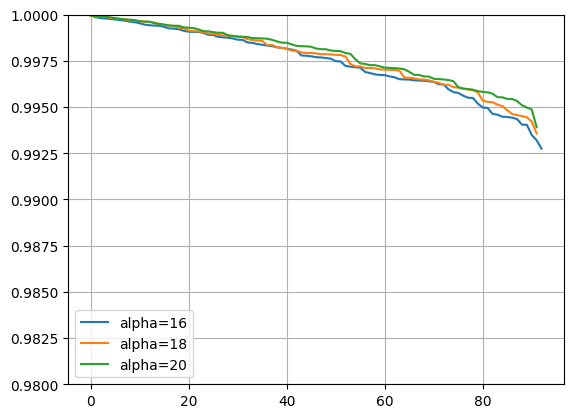

In [ ]:
for p in range(len(alphas)):
    Wf = Wfs[p]
    W0_ = np.array(W0.cpu()).T
    Q = W0_@np.array(Wf).T
    kc_sgd = 0 # number of learnable features by sgd
    qs_sgd = []
    for i in range(k):
        q_max = np.max(Q[i])
        if q_max > 0.5:
            kc_sgd += 1
            qs_sgd.append(q_max)

    v0_np = v0.cpu().numpy()
    vc_sgd = v0_np[kc_sgd-1]
    qs_sgd = np.sort(qs_sgd)[::-1]

    plt.plot(qs_sgd, label=f'alpha={alphas[p]}')
    print(kc_sgd)
plt.ylim(0.98,1)
plt.legend()
plt.grid()
plt.show()